In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

In [2]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
except ValueError:
    tpu = None

if tpu:
    policyConfig = "mixed_bfloat16"
else:
    policyConfig = "mixed_float16"
policy = tf.keras.mixed_precision.Policy(policyConfig)
tf.keras.mixed_precision.set_global_policy(policy)

In [3]:
train_dir = "/Users/shobhitkhinvasara/Documents/sneaker_classification/sneakers-dataset/train"
test_dir = "/Users/shobhitkhinvasara/Documents/sneaker_classification/sneakers-dataset/test"

In [4]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode="categorical",
                                                                 batch_size=32,
                                                                 image_size=(224,224),
                                                                 shuffle=True)
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                 label_mode="categorical",
                                                                 batch_size=32,
                                                                 image_size=(224,224),
                                                                 shuffle=False)

Found 5953 files belonging to 50 classes.
Found 285 files belonging to 50 classes.


In [5]:
class_names = train_data.class_names
class_names

['adidas_forum_high',
 'adidas_forum_low',
 'adidas_gazelle',
 'adidas_nmd_r1',
 'adidas_samba',
 'adidas_stan_smith',
 'adidas_superstar',
 'adidas_ultraboost',
 'asics_gel-lyte_iii',
 'converse_chuck_70_high',
 'converse_chuck_70_low',
 'converse_chuck_taylor_all-star_high',
 'converse_chuck_taylor_all-star_low',
 'converse_one_star',
 'new_balance_327',
 'new_balance_550',
 'new_balance_574',
 'new_balance_990',
 'new_balance_992',
 'nike_air_force_1_high',
 'nike_air_force_1_low',
 'nike_air_force_1_mid',
 'nike_air_jordan_11',
 'nike_air_jordan_1_high',
 'nike_air_jordan_1_low',
 'nike_air_jordan_3',
 'nike_air_jordan_4',
 'nike_air_max_1',
 'nike_air_max_270',
 'nike_air_max_90',
 'nike_air_max_95',
 'nike_air_max_97',
 'nike_air_max_plus_(tn)',
 'nike_air_vapormax_flyknit',
 'nike_air_vapormax_plus',
 'nike_blazer_mid_77',
 'nike_cortez',
 'nike_dunk_high',
 'nike_dunk_low',
 'puma_suede_classic',
 'reebok_classic_leather',
 'reebok_club_c_85',
 'salomon_xt-6',
 'vans_authentic'

In [6]:
def view_random_img(train_dir, target_class):
    directory = os.path.join(train_dir, target_class)
    random_img = random.sample(os.listdir(directory),1)

    img = mpimg.imread(os.path.join(directory, random_img[0]))
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off");

    return img

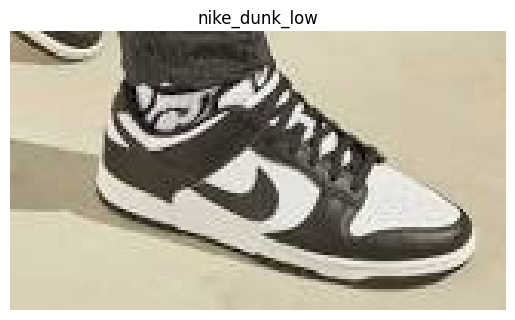

In [7]:
img = view_random_img(train_dir, random.choice(os.listdir(train_dir)))

In [8]:
checkpoint_path = "checkpoints/checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    save_best_only=True,
    monitor="val_accuracy",
    save_freq="epoch",
    verbose=1
)

In [9]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    verbose=1
)

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.02),
    #tf.keras.layers.RandomFlip(),
    #tf.keras.layers.Rescaling(1./255)
])

In [11]:
#base model
base_model = tf.keras.applications.EfficientNetV2M(include_top=False)
base_model.trainable=False
inputs = tf.keras.layers.Input(shape=(224,224,3), name="input_layer")
x = data_augmentation(inputs)
x = base_model(x, training=False)
#x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dense(len(class_names))(x)
outputs = tf.keras.layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)

model_0 = tf.keras.Model(inputs, outputs)
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"]
)


214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [12]:
model_0.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        64,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_2 (Cast)                   │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 50)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,214,438 (203.00 MB)

 Trainable params: 64,050 (250.20 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

In [14]:
model_0_loss = model_0.fit(train_data,
                           epochs=5,
                           validation_data=test_data,
                           validation_steps=int(0.15 * len(test_data)),
                           callbacks=[checkpoint_callback])

Epoch 1/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.3895 - loss: 2.6358
Epoch 1: val_accuracy improved from 0.31250 to 0.53125, saving model to checkpoints/checkpoint.weights.h5
187/187 ━━━━━━━━━━━━━━━━━━━━ 169s 904ms/step - accuracy: 0.3895 - loss: 2.6356 - val_accuracy: 0.5312 - val_loss: 2.2742
Epoch 2/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4479 - loss: 2.3611
Epoch 2: val_accuracy improved from 0.53125 to 0.65625, saving model to checkpoints/checkpoint.weights.h5
187/187 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.4480 - loss: 2.3609 - val_accuracy: 0.6562 - val_loss: 2.0146
Epoch 3/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 88s/step - accuracy: 0.4898 - loss: 2.1614  
Epoch 3: val_accuracy did not improve from 0.65625
187/187 ━━━━━━━━━━━━━━━━━━━━ 16351s 88s/step - accuracy: 0.4899 - loss: 2.1612 - val_accuracy: 0.6562 - val_loss: 1.8124
Epoch 4/5
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 168s/step - accuracy: 0.5316 - loss: 2.0147  
Epoch 4: val_accuracy did not i

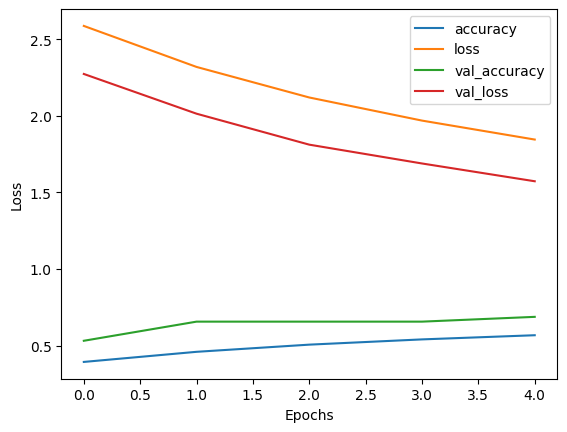

In [15]:
pd.DataFrame(model_0_loss.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [16]:

model_0.evaluate(test_data)

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 879ms/step - accuracy: 0.6239 - loss: 1.6872


[1.6800622940063477, 0.6315789222717285]

In [17]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable=False



In [18]:
model_0.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(0.0001),
                metrics=["accuracy"])

In [20]:
model_0_new_loss = model_0.fit(train_data,
                               epochs=10,
                               initial_epoch=model_0_loss.epoch[-1],
                               validation_data=test_data,
                               validation_steps=int(0.15 * len(test_data)))

Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 182s 975ms/step - accuracy: 0.6501 - loss: 1.3848 - val_accuracy: 0.8125 - val_loss: 0.8037
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 179s 958ms/step - accuracy: 0.7444 - loss: 1.0337 - val_accuracy: 0.8438 - val_loss: 0.6915
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 179s 959ms/step - accuracy: 0.7967 - loss: 0.8621 - val_accuracy: 0.9062 - val_loss: 0.5322
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 178s 950ms/step - accuracy: 0.8286 - loss: 0.7156 - val_accuracy: 0.9375 - val_loss: 0.3868
Epoch 9/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 182s 971ms/step - accuracy: 0.8607 - loss: 0.6091 - val_accuracy: 0.9688 - val_loss: 0.2790
Epoch 10/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 185s 992ms/step - accuracy: 0.8772 - loss: 0.5412 - val_accuracy: 0.9688 - val_loss: 0.2495


In [21]:
model_0.evaluate(test_data)

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 921ms/step - accuracy: 0.9523 - loss: 0.2909


[0.26783350110054016, 0.9543859362602234]

In [22]:
model_0.save("model_0.keras")

In [23]:
model = tf.keras.models.load_model("model_0.keras")

In [24]:
results = model.evaluate(test_data)
pred_probs = model.predict(test_data, verbose=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 876ms/step - accuracy: 0.9523 - loss: 0.2909
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step 


In [25]:
pred_classes = pred_probs.argmax(axis=1)
pred_classes

array([ 0,  0,  1,  1,  1,  2,  2,  2,  3,  3,  3,  3,  4,  4,  4,  4,  4,
        5,  5,  5,  5,  6,  6,  6,  6,  6,  5,  7,  7,  7,  7,  7,  7,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9, 10, 10, 10, 13, 10, 10,
       11, 11, 11, 11, 11, 11, 12, 12,  5, 12, 12, 12, 13, 13, 13, 10, 13,
       13, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16,
       16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 21, 37, 19,
        0, 21, 19, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 22, 22,
       22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 24,  7, 24, 24, 24, 24, 25,
       25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 26, 27, 27, 27, 27, 27, 27,
       28, 28, 28, 28, 28, 28, 29, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30,
       30, 31, 31, 31, 31, 29, 31, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33,
       33, 33, 34, 34, 34, 34, 34, 34, 35, 35, 35, 35, 35, 35, 36, 36, 36,
       36, 36, 36, 37, 37, 37, 37, 37, 37, 38, 38, 38, 38, 38, 38, 39, 39,
       39, 39, 39, 39, 40

In [26]:
y_labels = [labels.numpy().argmax() for images, labels in test_data.unbatch()]
y_labels

2025-05-10 11:34:26.924008: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


[np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(7),
 np.int64(7),
 np.int64(7),
 np.int64(7),
 np.int64(7),
 np.int64(7),
 np.int64(8),
 np.int64(8),
 np.int64(8),
 np.int64(8),
 np.int64(8),
 np.int64(8),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(9),
 np.int64(10),
 np.int64(10),
 np.int64(10),
 np.int64(10),
 np.int64(10),
 np.int64(10),
 np.int64(11),
 np.int64(11),
 np.int64(11),
 np.int64(11),
 np.int64(11),
 np.int64(11),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(12),
 np.int64(13),
 np.int64(13),
 np.int64(13),
 np.int64(13),
 np.int64(13),
 np.int64(13),
 np.int64(

In [27]:
from sklearn.metrics import accuracy_score
sk_acc = accuracy_score(y_true=y_labels, y_pred=pred_classes)
sk_acc

0.9543859649122807

In [28]:
class_names

['adidas_forum_high',
 'adidas_forum_low',
 'adidas_gazelle',
 'adidas_nmd_r1',
 'adidas_samba',
 'adidas_stan_smith',
 'adidas_superstar',
 'adidas_ultraboost',
 'asics_gel-lyte_iii',
 'converse_chuck_70_high',
 'converse_chuck_70_low',
 'converse_chuck_taylor_all-star_high',
 'converse_chuck_taylor_all-star_low',
 'converse_one_star',
 'new_balance_327',
 'new_balance_550',
 'new_balance_574',
 'new_balance_990',
 'new_balance_992',
 'nike_air_force_1_high',
 'nike_air_force_1_low',
 'nike_air_force_1_mid',
 'nike_air_jordan_11',
 'nike_air_jordan_1_high',
 'nike_air_jordan_1_low',
 'nike_air_jordan_3',
 'nike_air_jordan_4',
 'nike_air_max_1',
 'nike_air_max_270',
 'nike_air_max_90',
 'nike_air_max_95',
 'nike_air_max_97',
 'nike_air_max_plus_(tn)',
 'nike_air_vapormax_flyknit',
 'nike_air_vapormax_plus',
 'nike_blazer_mid_77',
 'nike_cortez',
 'nike_dunk_high',
 'nike_dunk_low',
 'puma_suede_classic',
 'reebok_classic_leather',
 'reebok_club_c_85',
 'salomon_xt-6',
 'vans_authentic'

In [29]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15, norm=False, savefig=False): 
 
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] 
  n_classes = cm.shape[0] 


  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.RdPu) 
  fig.colorbar(cax)


  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])
  

  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), 
         yticks=np.arange(n_classes), 
         xticklabels=labels) 
  
  
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  plt.xticks(rotation=70, fontsize=text_size)
  plt.yticks(fontsize=text_size)
  threshold = (cm.max() + cm.min()) / 2.

  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  if savefig:
    fig.savefig("confusion_matrix.png")

In [30]:
make_confusion_matrix(y_true=y_labels, y_pred=pred_classes, classes=class_names, figsize=(100,100), text_size=30)

In [33]:
def load_and_prep_image(filename, img_shape=224, scale=True):
  print(filename)
  img = tf.io.read_file(filename)
  img = tf.io.decode_image(img, channels=3)
  img = tf.image.resize(img, [img_shape, img_shape])
  if scale:
    return img/255.
  else:
    return img

/Users/shobhitkhinvasara/Documents/sneaker_classification/sneakers-dataset/test/nike_air_force_1_high/0071.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
/Users/shobhitkhinvasara/Documents/sneaker_classification/sneakers-dataset/test/nike_air_max_plus_(tn)/0070.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
/Users/shobhitkhinvasara/Documents/sneaker_classification/sneakers-dataset/test/nike_air_jordan_3/0071.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


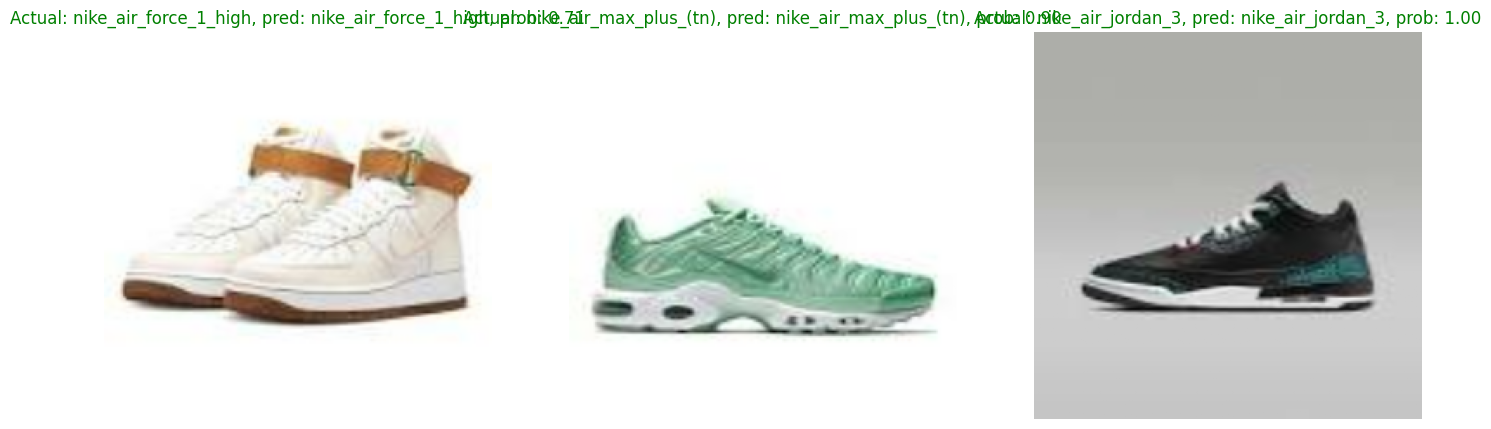

In [34]:
plt.figure(figsize=(17,10))
for i in range(3):
  class_name = random.choice(class_names)
  filename = random.choice(os.listdir(test_dir+"/"+class_name))
  filepath = test_dir + "/" + class_name + "/" + filename

  img = load_and_prep_image(filepath, scale=False)
  img_expanded = tf.expand_dims(img, axis=0)
  pred_prob = model.predict(img_expanded)
  pred_class = class_names[pred_prob.argmax()]

  plt.subplot(1,3,i+1)
  plt.imshow(img/255.)
  if class_name == pred_class:
    title_color = "g"
  else:
    title_color = "r"

  plt.title(f"Actual: {class_name}, pred: {pred_class}, prob: {pred_prob.max():.2f}", c=title_color)
  plt.axis("off");

In [37]:
img_dir = "/Users/shobhitkhinvasara/Documents/inference/actions"

/Users/shobhitkhinvasara/Documents/inference/actions/0006.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
/Users/shobhitkhinvasara/Documents/inference/actions/0001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


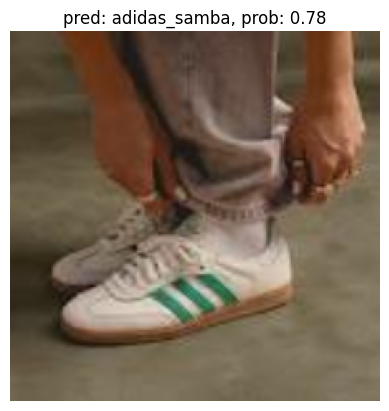

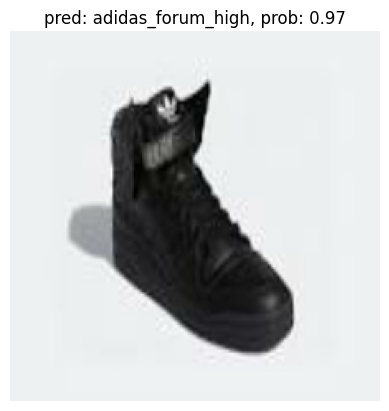

In [38]:
for image in os.listdir(img_dir):
    img = load_and_prep_image(os.path.join(img_dir,image), scale=False)
    pred_prob = model.predict(tf.expand_dims(img, axis=0))
    pred_class = class_names[pred_prob.argmax()]

    plt.figure()
    plt.imshow(img/255.)
    plt.title(f"pred: {pred_class}, prob: {pred_prob.max():.2f}")
    plt.axis('off');